In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [2]:
# If using Kaggle API
!pip install kaggle

from google.colab import files
files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d muratkokludataset/rice-image-dataset
!unzip rice-image-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (55).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (550).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5500).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5501).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5502).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5503).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5504).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5505).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5506).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5507).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5508).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5509).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (551).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5510).jpg  
  inflating: Rice_Image_Dataset/Karacadag/K

In [4]:
import os
import shutil
import random

SOURCE_DIR = "Rice_Image_Dataset"
TARGET_DIR = "Rice_Balanced_600"
IMAGES_PER_CLASS = 600

os.makedirs(TARGET_DIR, exist_ok=True)

for class_name in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        random.shuffle(images)

        selected_images = images[:IMAGES_PER_CLASS]

        target_class_path = os.path.join(TARGET_DIR, class_name)
        os.makedirs(target_class_path, exist_ok=True)

        for img in selected_images:
            src = os.path.join(class_path, img)
            dst = os.path.join(target_class_path, img)
            shutil.copy(src, dst)

print("✅ Done: 600 images per class copied.")

✅ Done: 600 images per class copied.


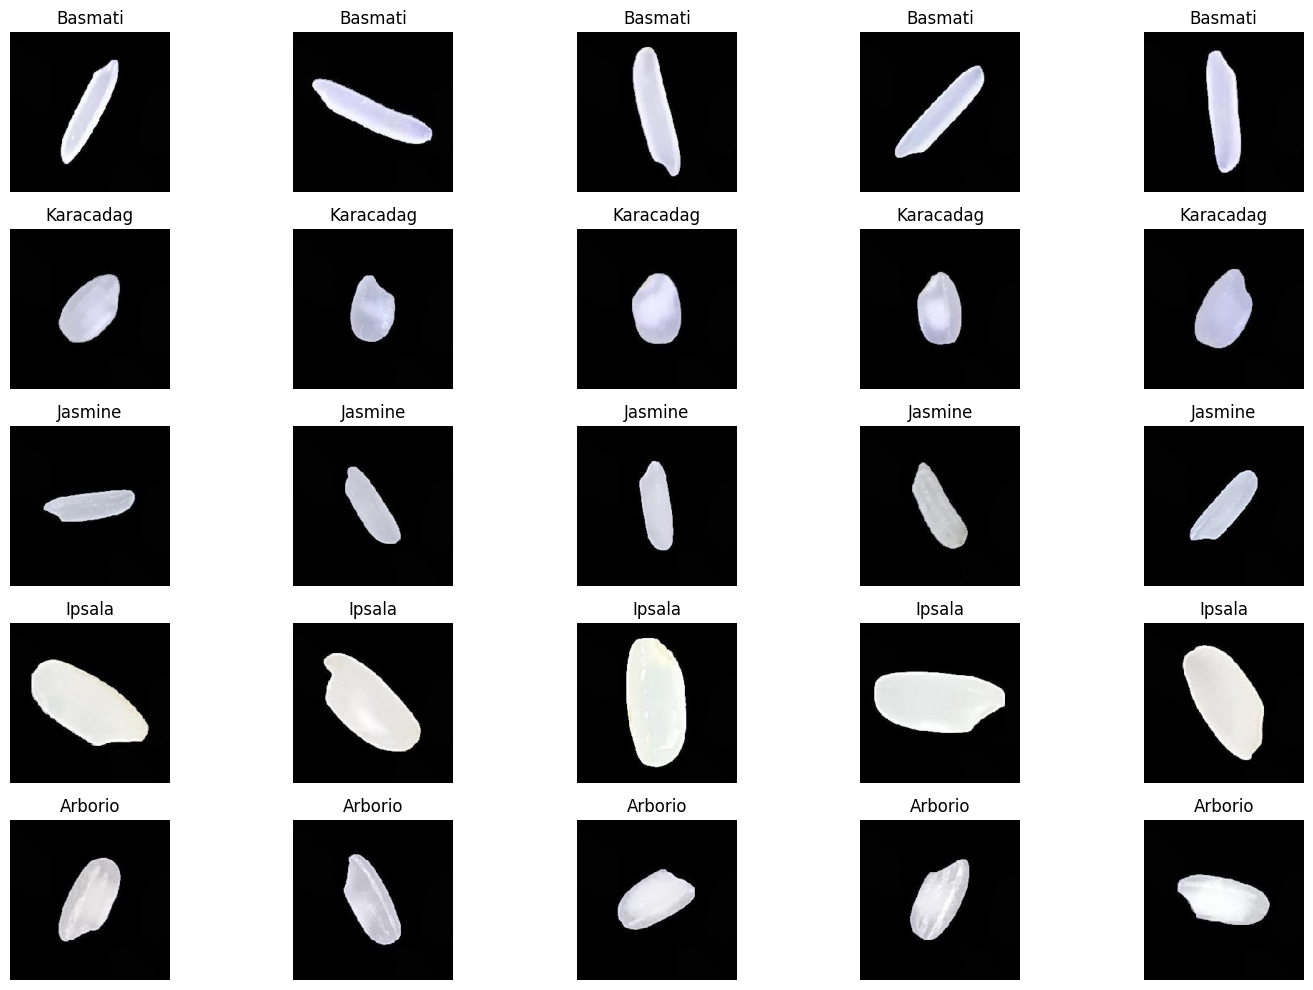

In [6]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing.image import load_img

DATASET_PATH = "/content/Rice_Balanced_600"

def show_samples(dataset_path, samples_per_class=5):
    plt.figure(figsize=(15, 10))
    plot_index = 1

    for class_name in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_name)

        if os.path.isdir(class_path):
            images = os.listdir(class_path)
            selected = random.sample(images, samples_per_class)

            for img_name in selected:
                img_path = os.path.join(class_path, img_name)
                img = load_img(img_path, target_size=(224, 224))

                plt.subplot(len(os.listdir(dataset_path)), samples_per_class, plot_index)
                plt.imshow(img)
                plt.title(class_name)
                plt.axis("off")

                plot_index += 1

    plt.tight_layout()
    plt.show()

show_samples(DATASET_PATH)

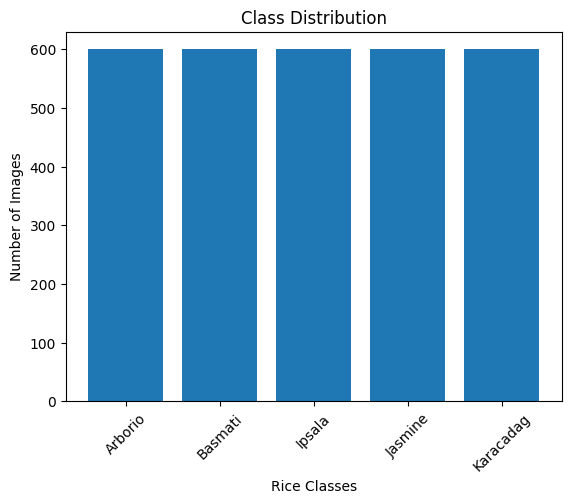

In [29]:
import matplotlib.pyplot as plt
import numpy as np

labels = train_data.classes
class_names = list(train_data.class_indices.keys())

# Count samples per class
counts = np.bincount(labels)

plt.figure()
plt.bar(class_names, counts)

plt.title("Class Distribution")
plt.xlabel("Rice Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

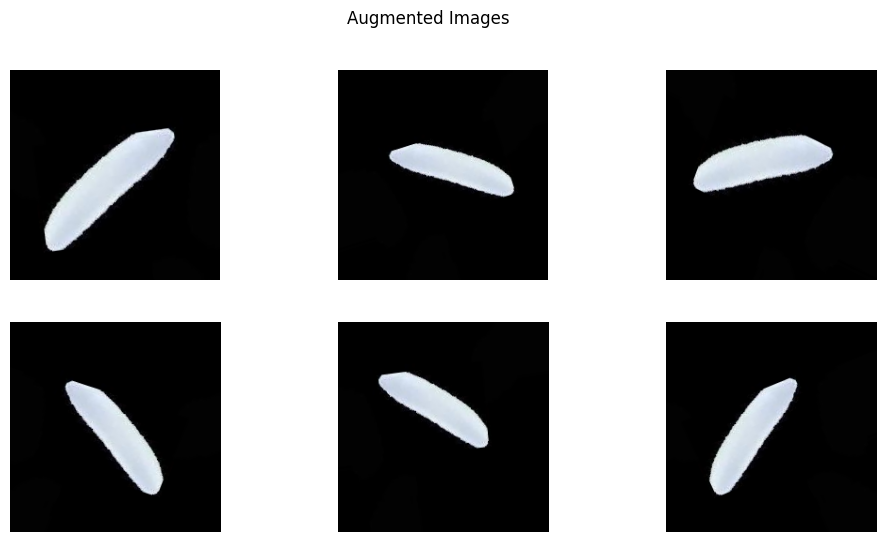

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
import numpy as np

# Define augmentations (same as training)
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

def show_augmentations(image_path, num_aug=6):
    img = load_img(image_path, target_size=(224, 224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)

    plt.figure(figsize=(12, 6))

    i = 1
    for batch in aug_datagen.flow(x, batch_size=1):
        plt.subplot(2, 3, i)
        plt.imshow(batch[0])
        plt.axis('off')
        i += 1
        if i > num_aug:
            break

    plt.suptitle("Augmented Images")
    plt.show()

sample_image = "/content/Rice_Image_Dataset/Basmati/basmati (10002).jpg"
show_augmentations(sample_image)

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 🔥 Training Data (WITH augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    # ✅ Augmentations
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ❗ Validation Data (NO augmentation, only rescale)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# 📂 Train
train_data = train_datagen.flow_from_directory(
    '/content/Rice_Balanced_600',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# 📂 Validation
val_data = val_datagen.flow_from_directory(
    '/content/Rice_Balanced_600',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2400 images belonging to 5 classes.
Found 600 images belonging to 5 classes.


In [10]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    '/content/Rice_Balanced_600',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 5 classes.


In [11]:
base_model_mob = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model_mob.trainable = False  # freeze base

mobilenet_model = models.Sequential([
    base_model_mob,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,717 (9.26 MB)

 Trainable params: 167,173 (653.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [12]:
history_mob = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.8650 - loss: 0.4028 - val_accuracy: 0.8700 - val_loss: 0.3704
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.9321 - loss: 0.2152 - val_accuracy: 0.8900 - val_loss: 0.3113
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.9362 - loss: 0.1827 - val_accuracy: 0.9467 - val_loss: 0.1229
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.9396 - loss: 0.1663 - val_accuracy: 0.9567 - val_loss: 0.1136
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.9517 - loss: 0.1407 - val_accuracy: 0.9517 - val_loss: 0.1208
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.9542 - loss: 0.1416 - val_accuracy: 0.9483 - val_loss: 0.1123
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.9550 - loss: 0.1282 - val_accuracy: 0.9550 - val_loss: 0.1056
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.9533 - loss: 0.1287 - val_accuracy: 0.9450 - v

In [13]:
base_model_inc = InceptionV3(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model_inc.trainable = False

inception_model = models.Sequential([
    base_model_inc,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

inception_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

inception_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,336,805 (85.21 MB)

 Trainable params: 529,925 (2.02 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [14]:
history_inc = inception_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 412s 5s/step - accuracy: 0.8708 - loss: 0.4782 - val_accuracy: 0.8617 - val_loss: 0.3706
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 434s 5s/step - accuracy: 0.9192 - loss: 0.3002 - val_accuracy: 0.9283 - val_loss: 0.1952
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 393s 5s/step - accuracy: 0.9392 - loss: 0.2216 - val_accuracy: 0.9533 - val_loss: 0.1662
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 394s 5s/step - accuracy: 0.9400 - loss: 0.2844 - val_accuracy: 0.9633 - val_loss: 0.0952
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 394s 5s/step - accuracy: 0.9375 - loss: 0.2279 - val_accuracy: 0.9600 - val_loss: 0.1120
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 401s 5s/step - accuracy: 0.9400 - loss: 0.2156 - val_accuracy: 0.9600 - val_loss: 0.1368
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 394s 5s/step - accuracy: 0.9546 - loss: 0.1699 - val_accuracy: 0.9767 - val_loss: 0.0897
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 393s 5s/step - accuracy: 0.9550 - loss: 0.1627 - val_accuracy: 0.9633 - v

In [15]:
def evaluate_model(model, val_data, name):
    loss, acc = model.evaluate(val_data)
    print(f"{name} Accuracy: {acc:.4f}")

In [16]:
evaluate_model(mobilenet_model, val_data, "MobileNet")
evaluate_model(inception_model, val_data, "InceptionV3")

19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9467 - loss: 0.1497
MobileNet Accuracy: 0.9467
19/19 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.9717 - loss: 0.0832
InceptionV3 Accuracy: 0.9717


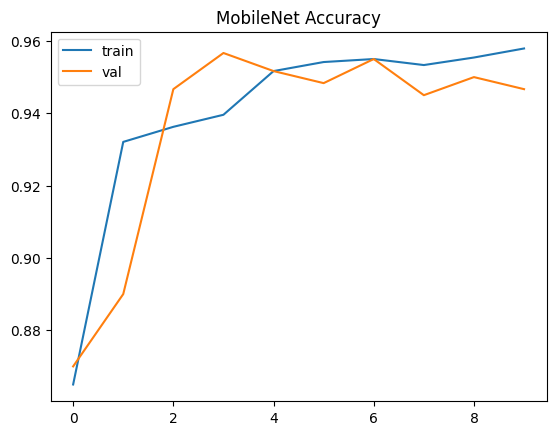

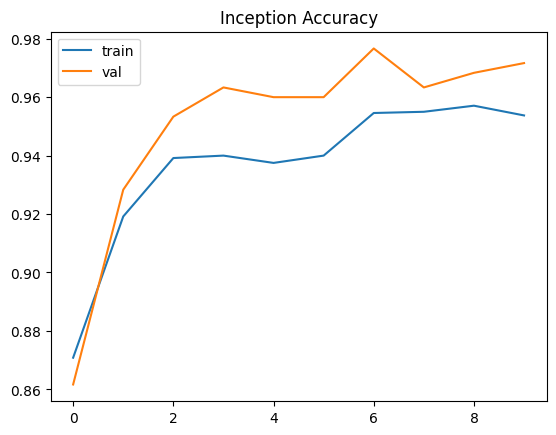

In [17]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(history_mob, "MobileNet Accuracy")
plot_history(history_inc, "Inception Accuracy")

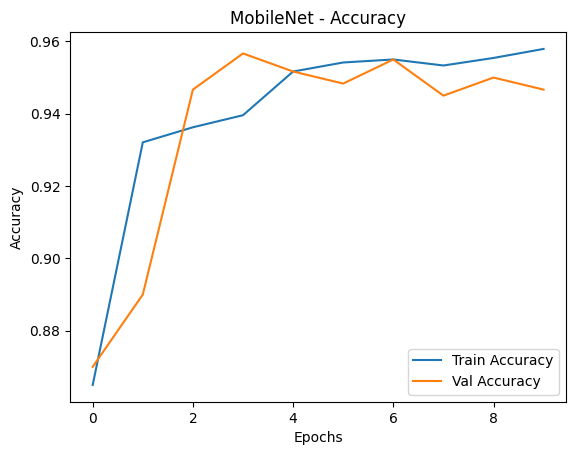

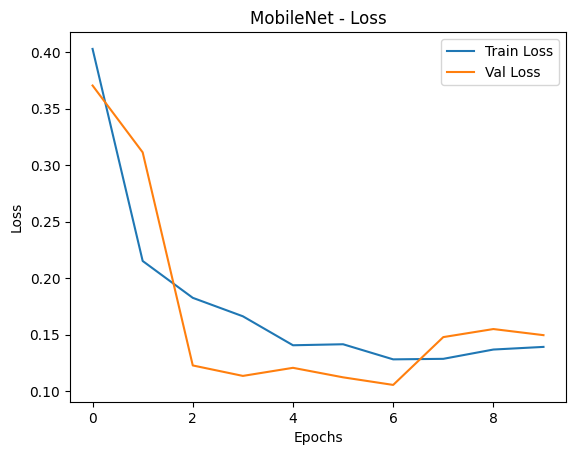

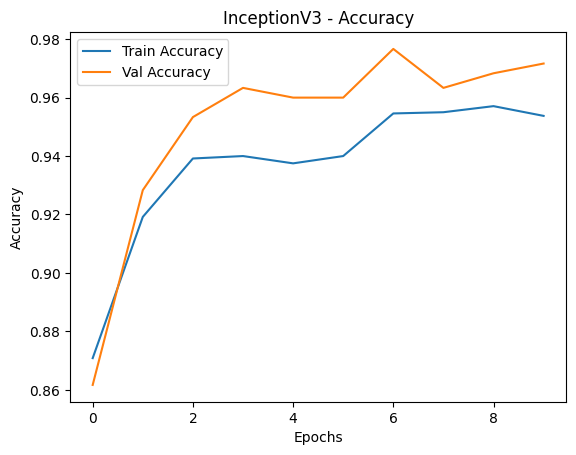

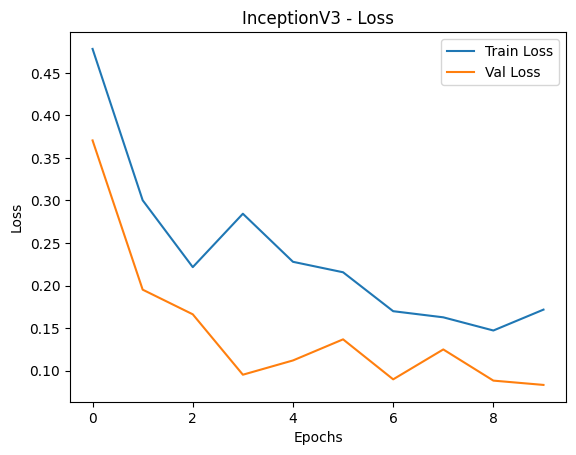

In [18]:
import matplotlib.pyplot as plt

def plot_training(history, title):
    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_training(history_mob, "MobileNet")
plot_training(history_inc, "InceptionV3")

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

In [20]:
# True labels
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())
n_classes = len(class_names)

# MobileNet
y_prob_mob = mobilenet_model.predict(test_data)
y_pred_mob = np.argmax(y_prob_mob, axis=1)

# Inception
y_prob_inc = inception_model.predict(test_data)
y_pred_inc = np.argmax(y_prob_inc, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 370s 4s/step


MobileNet Test Accuracy: 0.9503
InceptionV3 Test Accuracy: 0.9820


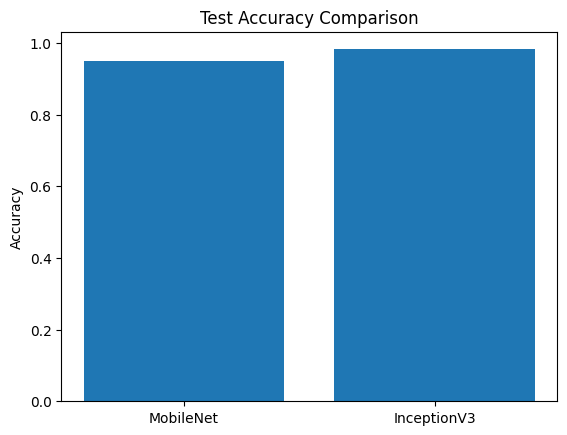

In [21]:
acc_mob = np.mean(y_pred_mob == y_true)
acc_inc = np.mean(y_pred_inc == y_true)

print(f"MobileNet Test Accuracy: {acc_mob:.4f}")
print(f"InceptionV3 Test Accuracy: {acc_inc:.4f}")

# Plot
plt.figure()
plt.bar(["MobileNet", "InceptionV3"], [acc_mob, acc_inc])
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

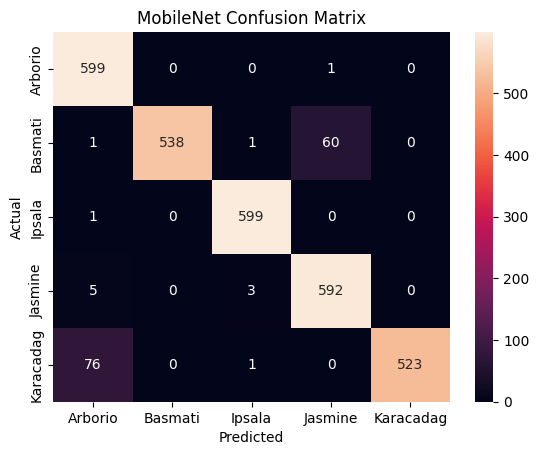

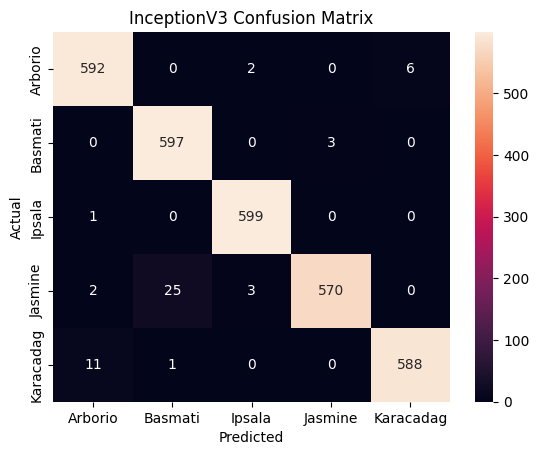

In [22]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_true, y_pred_mob, "MobileNet Confusion Matrix")
plot_cm(y_true, y_pred_inc, "InceptionV3 Confusion Matrix")

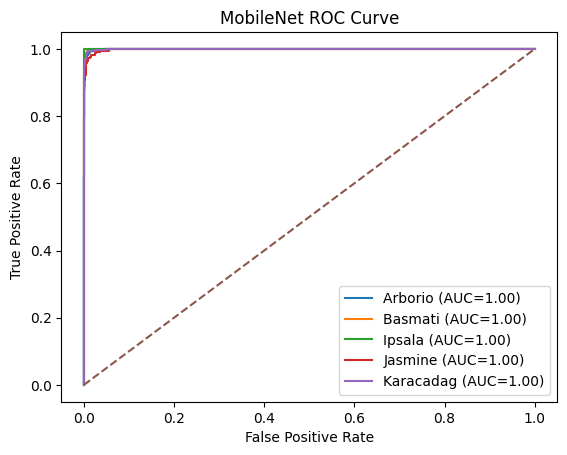

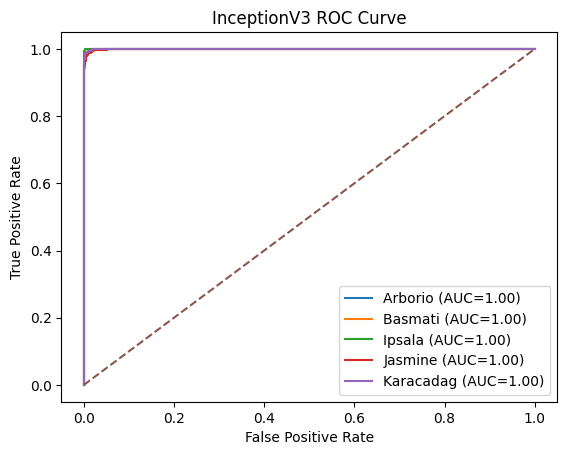

In [23]:
# One-hot encode true labels
y_true_bin = label_binarize(y_true, classes=range(n_classes))

def plot_roc(y_true_bin, y_prob, title):
    plt.figure()
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'--')
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

plot_roc(y_true_bin, y_prob_mob, "MobileNet ROC Curve")
plot_roc(y_true_bin, y_prob_inc, "InceptionV3 ROC Curve")

In [24]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_class_metrics(y_true, y_pred, class_names, title):
    # Get report as dict
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True
    )

    # Convert to DataFrame (only classes)
    df = pd.DataFrame(report).transpose().iloc[:len(class_names)]

    x = np.arange(len(class_names))
    width = 0.25

    plt.figure()
    plt.bar(x - width, df['precision'], width, label='Precision')
    plt.bar(x, df['recall'], width, label='Recall')
    plt.bar(x + width, df['f1-score'], width, label='F1-score')

    plt.xticks(x, class_names, rotation=45)
    plt.title(title)
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

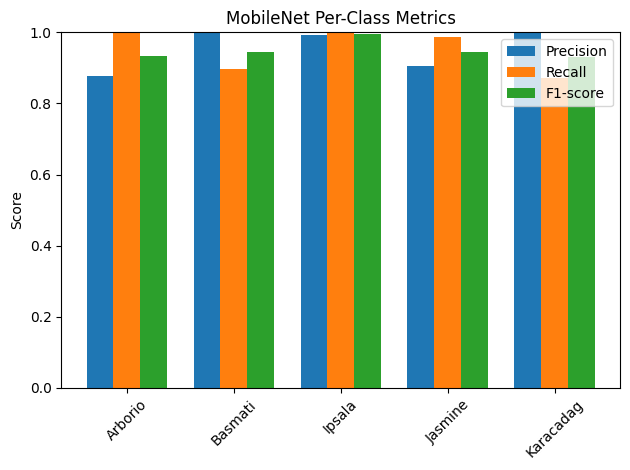

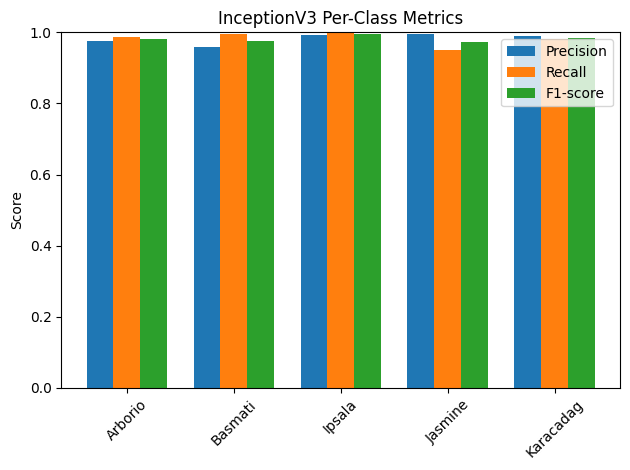

In [25]:
plot_class_metrics(y_true, y_pred_mob, class_names, "MobileNet Per-Class Metrics")
plot_class_metrics(y_true, y_pred_inc, class_names, "InceptionV3 Per-Class Metrics")

In [27]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return acc, precision, recall, f1

# 📌 MobileNet metrics
acc_mob, prec_mob, rec_mob, f1_mob = evaluate_metrics(y_true, y_pred_mob)

# 📌 Inception metrics
acc_inc, prec_inc, rec_inc, f1_inc = evaluate_metrics(y_true, y_pred_inc)

# 📊 Create DataFrame
comparison_df = pd.DataFrame({
    "Model": ["MobileNetV2", "InceptionV3"],
    "Accuracy": [acc_mob, acc_inc],
    "Precision": [prec_mob, prec_inc],
    "Recall": [rec_mob, rec_inc],
    "F1-Score": [f1_mob, f1_inc]
})

print(comparison_df)

         Model  Accuracy  Precision    Recall  F1-Score
0  MobileNetV2  0.950333   0.955321  0.950333  0.950276
1  InceptionV3  0.982000   0.982310  0.982000  0.981971
